In [9]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [10]:
!pip install -q ultralytics roboflow

In [11]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(15)
dataset = version.download("yolov8")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-15 in yolov8:: 100%|██████████| 646/646 [00:00<00:00, 6946.90it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

In [13]:
%cd {HOME}

!yolo task=pose mode=train model=yolo26x-pose.pt data={dataset.location}/data.yaml batch=12 epochs=100 imgsz=640 mosaic=0.0 plots=True

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/football-field-detection-15/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [15]:
!ls {HOME}/runs/pose/train5/

args.yaml			 PoseP_curve.png      train_batch1.jpg
BoxF1_curve.png			 PosePR_curve.png     train_batch2.jpg
BoxP_curve.png			 PoseR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1980.jpg  weights
labels.jpg			 train_batch1981.jpg
PoseF1_curve.png		 train_batch1982.jpg


/content


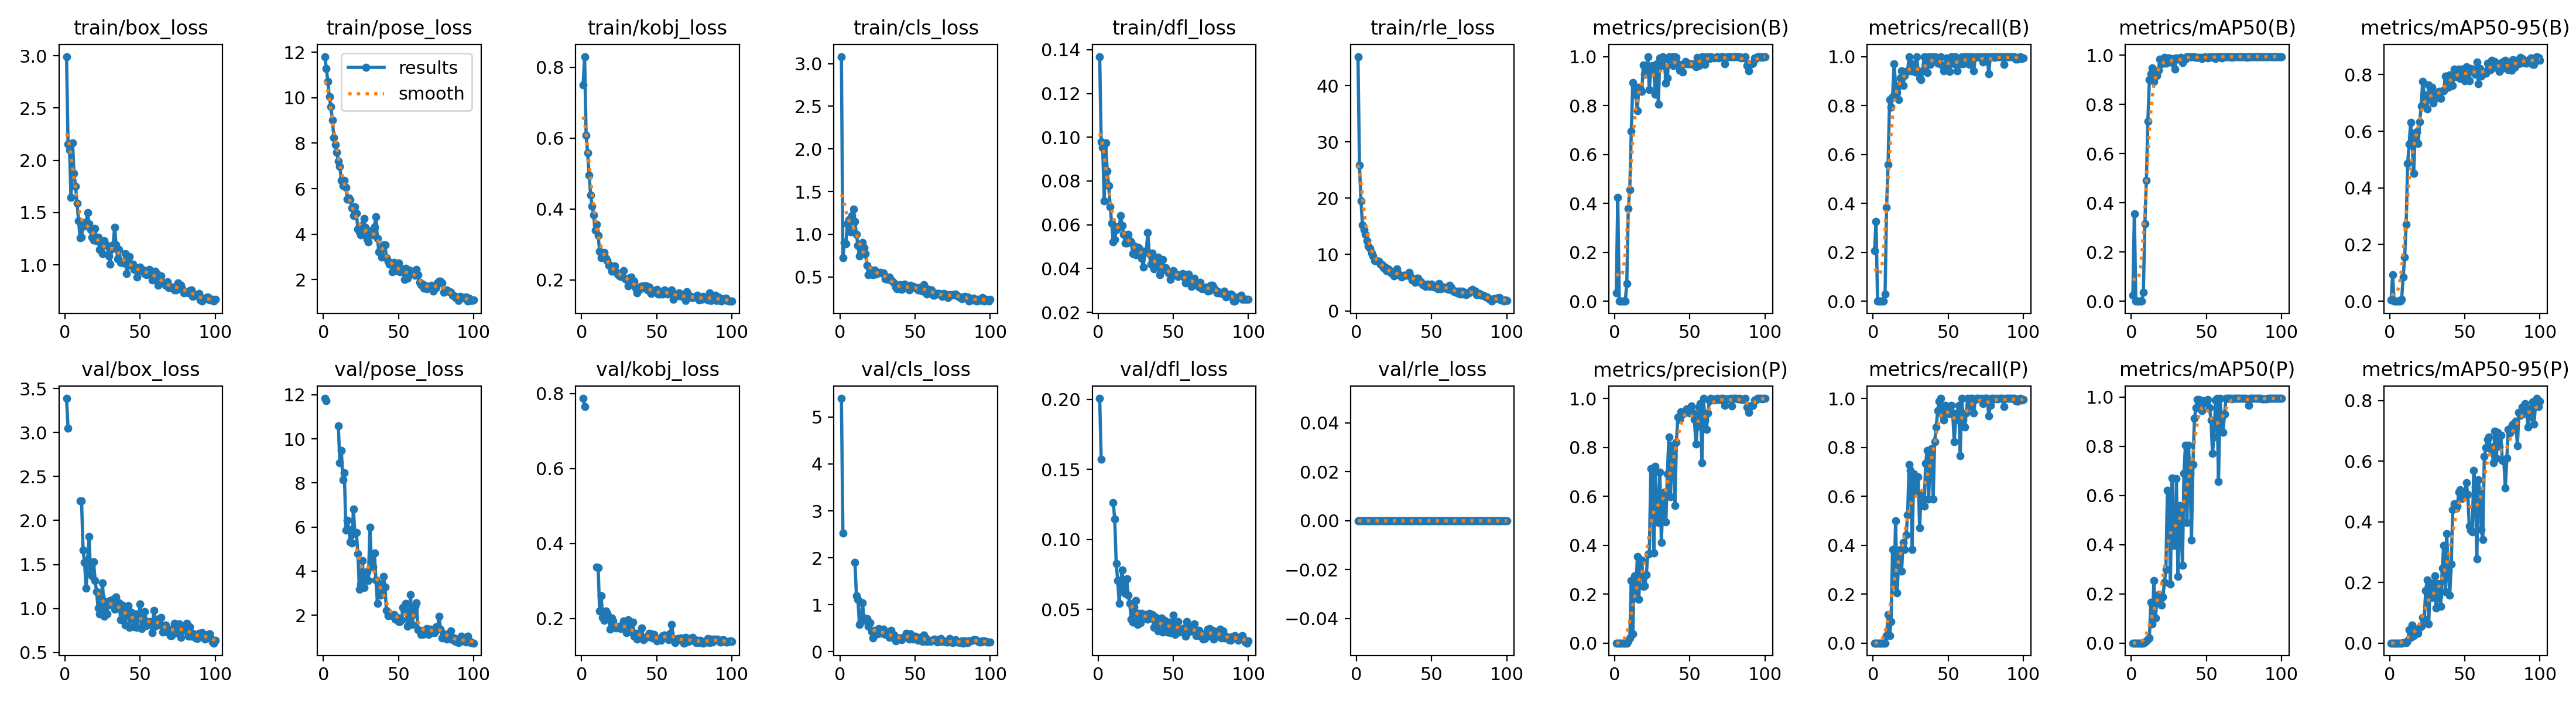

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train5/results.png', width=600)

/content


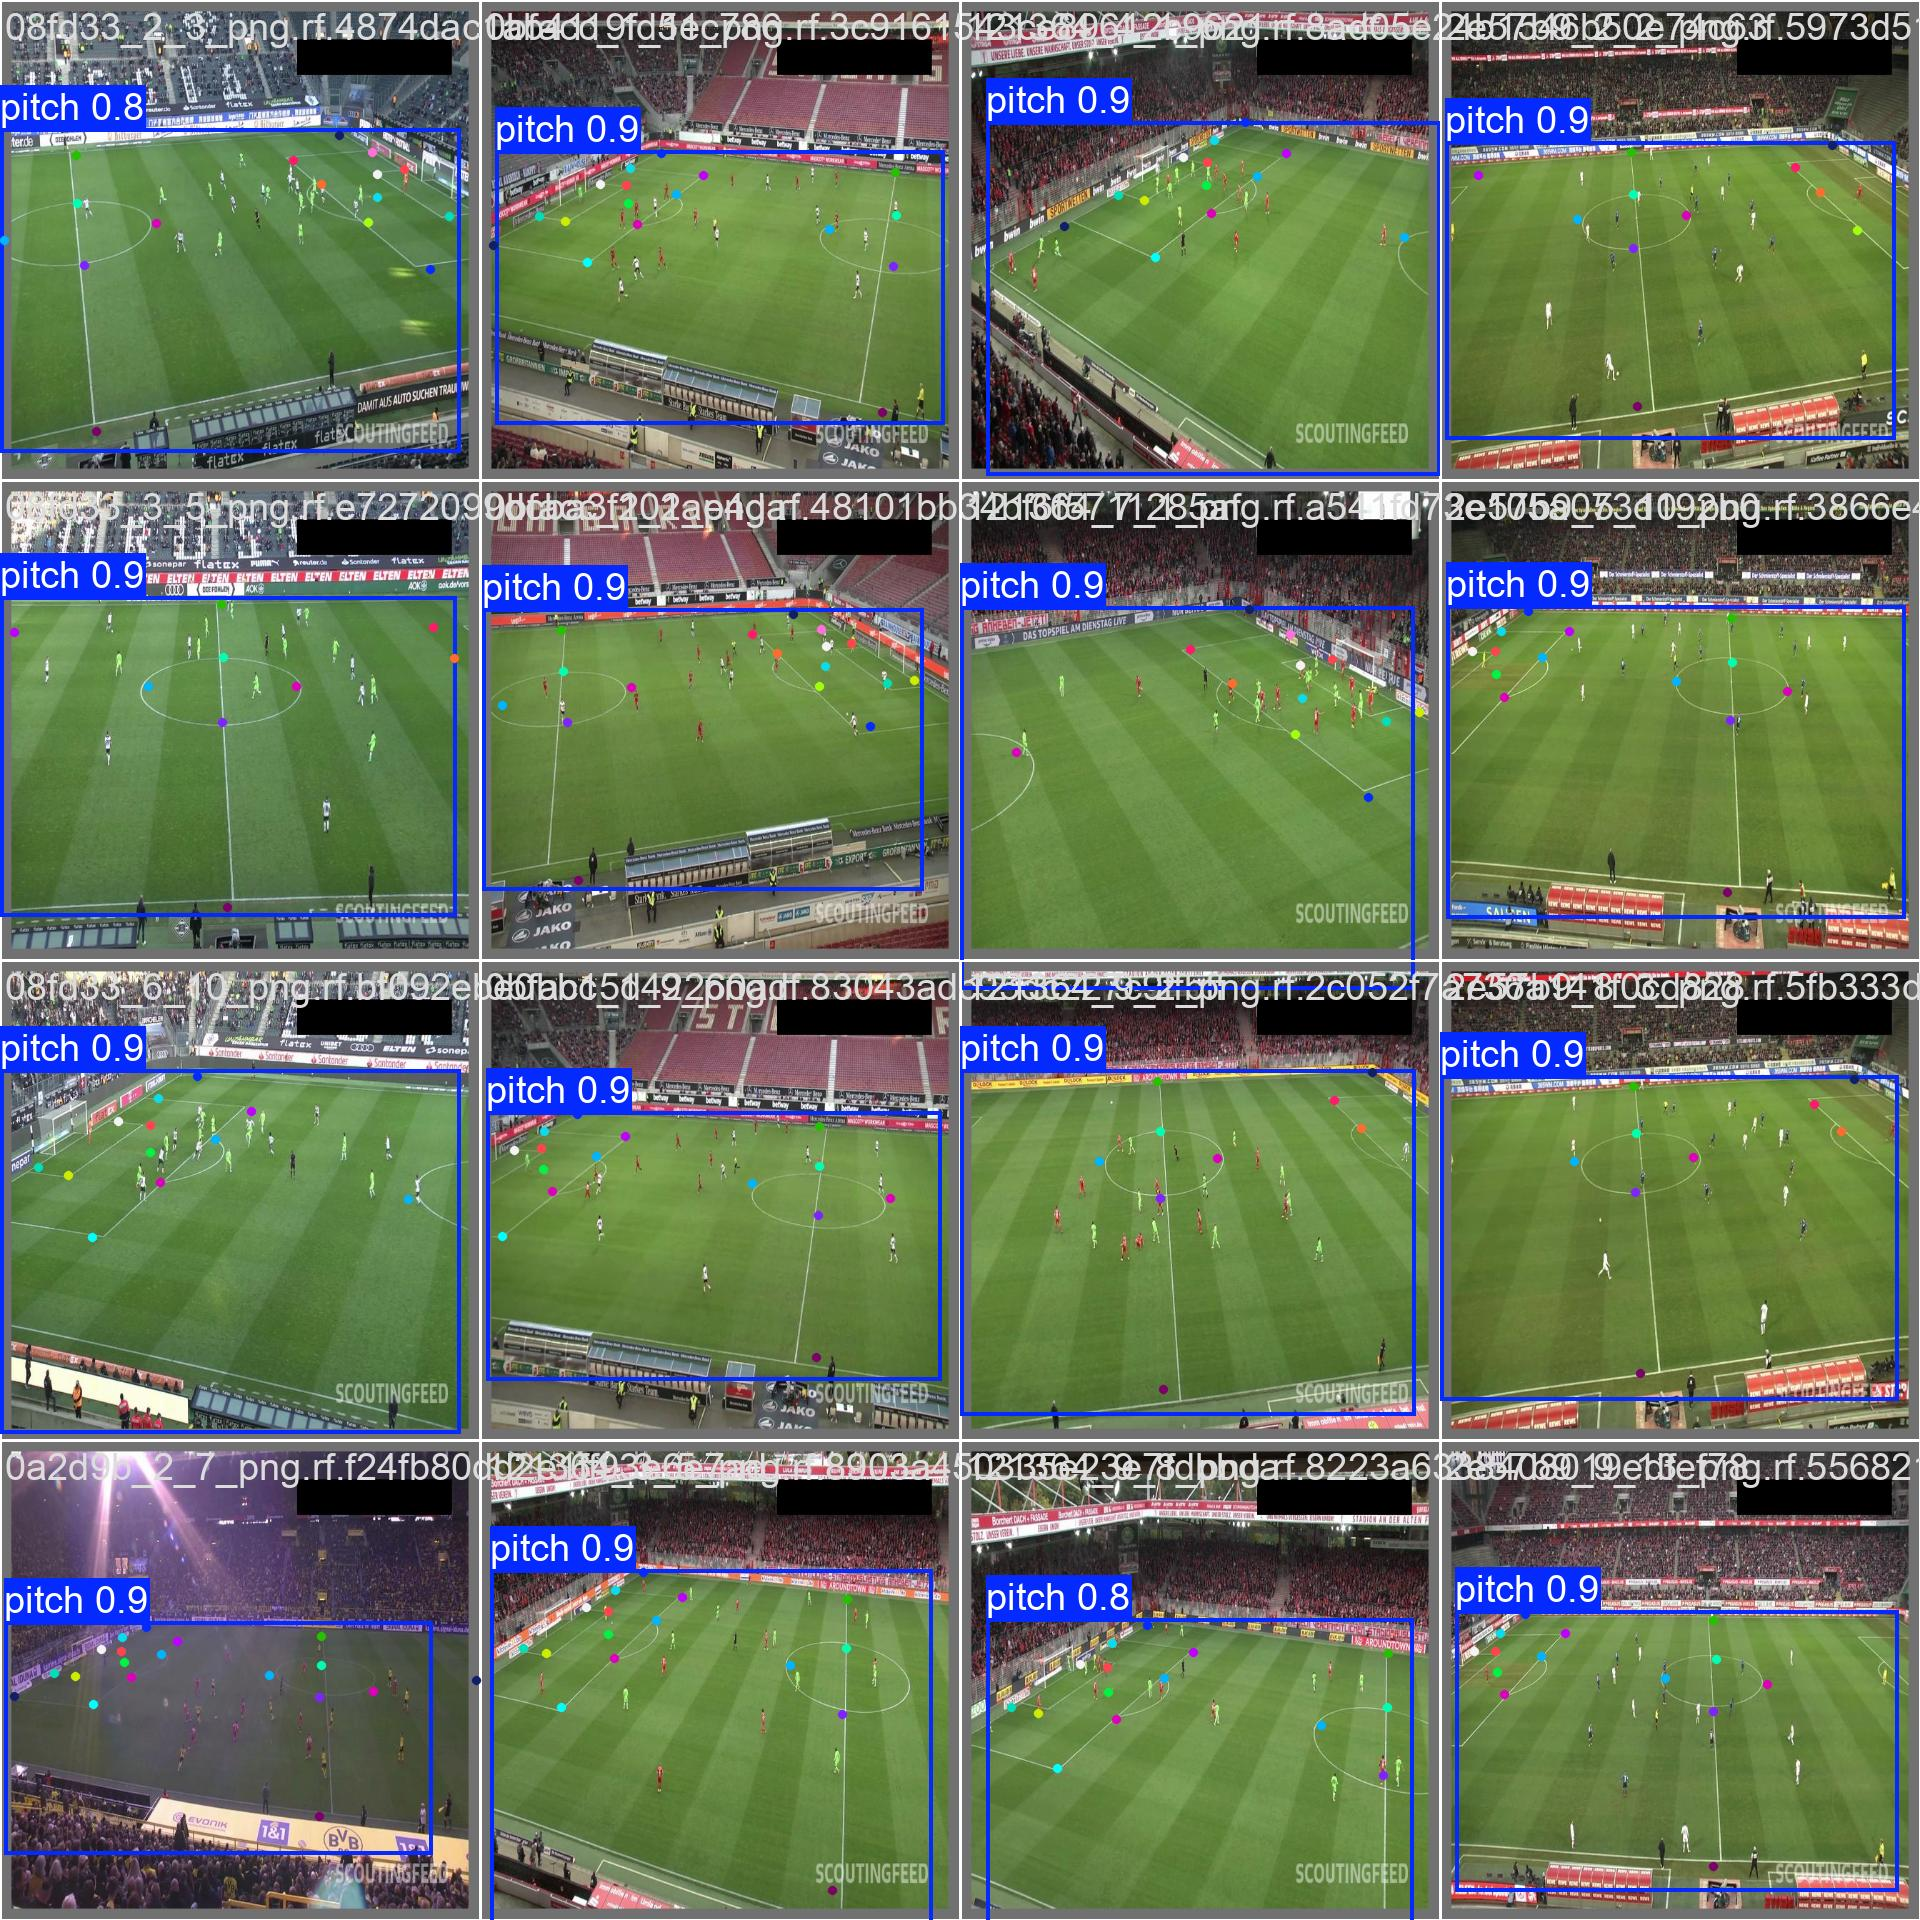

In [17]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train5/val_batch0_pred.jpg', width=600)

In [18]:
%cd {HOME}

!yolo task=pose mode=val model={HOME}/runs/pose/train5/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26x-pose summary (fused): 200 layers, 59,138,031 parameters, 0 gradients, 209.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2276.4±675.0 MB/s, size: 64.9 KB)
val: Scanning /content/datasets/football-field-detection-15/valid/labels.cache... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.4s
                   all         34         34      0.997          1      0.995      0.864      0.997          1      0.995      0.804
Speed: 9.4ms preprocess, 76.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val
